In [ ]:
# importing of modules for CIFAR-100 CNN
from tensorflow.keras.datasets import cifar100
from tensorflow.keras import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import SGD

# importing of service libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import itertools

print('Libraries imported.')

Libraries imported.


In [ ]:
# Fixed training constants
N_EPOCH = 30
N_CLASSES = 100
VERBOSE = 1
VALIDATION_SPLIT = 0.2

# CIFAR-100: 60K images, 32x32 pixels, 3 colour channels
IMG_CHANNELS = 3
IMG_ROWS = 32
IMG_COLS = 32

# 3 x 3 x 3 Grid experiment variables
BATCH_SIZE_OPTIONS    = [64, 128, 256]
LEARNING_RATE_OPTIONS = [0.001, 0.01, 0.1]
DROPOUT_RATE_OPTIONS  = [0.1, 0.25, 0.4]

print('Configuration set.')

Configuration set.


In [ ]:
# Load dataset
(input_X_train, output_y_train), (input_X_test, output_y_test) = cifar100.load_data()
print('input_X_train shape:', input_X_train.shape)
print(input_X_train.shape[0], 'train samples')
print(input_X_test.shape[0], 'test samples')

# Convert to categorical
output_Y_train = utils.to_categorical(output_y_train, N_CLASSES)
output_Y_test  = utils.to_categorical(output_y_test,  N_CLASSES)

# Float and normalisation
input_X_train = input_X_train.astype('float32') / 255
input_X_test  = input_X_test.astype('float32')  / 255

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
input_X_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


In [ ]:
def build_model(learning_rate, dropout_rate):

    model = Sequential()

    # Block 1: 2x Conv(32)
    model.add(Conv2D(32, (3, 3), padding='same',
                     input_shape=(IMG_ROWS, IMG_COLS, IMG_CHANNELS)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(Conv2D(32, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(dropout_rate))

    # Block 2: 2x Conv(64)
    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(dropout_rate))

    # Block 3: 2x Conv(128)
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(dropout_rate))

    # Block 4: 2x Conv(256)
    model.add(Conv2D(256, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(Conv2D(256, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(dropout_rate))

    # Classifier head: two dense layers
    model.add(Flatten())

    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(dropout_rate))

    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(dropout_rate))

    model.add(Dense(N_CLASSES))
    model.add(Activation('softmax'))

    # Compile
    optim = SGD(learning_rate=learning_rate, momentum=0.9)
    model.compile(loss='categorical_crossentropy',
                  optimizer=optim,
                  metrics=['accuracy'])
    return model

# Print a sample summary to confirm architecture
sample_model = build_model(learning_rate=0.01, dropout_rate=0.25)
sample_model.summary()
print('build_model() defined.')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             

 Total params: 1,860,996 (7.10 MB)

 Trainable params: 1,857,540 (7.09 MB)

 Non-trainable params: 3,456 (13.50 KB)

build_model() defined.


In [ ]:
# 3 x 3 x 3 Grid Experiment
# Variables: batch size, learning rate, dropout rate
results = []

grid = list(itertools.product(BATCH_SIZE_OPTIONS,
                               LEARNING_RATE_OPTIONS,
                               DROPOUT_RATE_OPTIONS))
total = len(grid)

for run_idx, (batch_size, lr, dropout_rate) in enumerate(grid, start=1):
    run_label = (f"Run {run_idx:02d}/{total} | "
                 f"BS={batch_size} | LR={lr} | DR={dropout_rate}")
    print(f"\n{'='*65}")
    print(run_label)
    print(f"{'='*65}")

    model = build_model(learning_rate=lr, dropout_rate=dropout_rate)

    history = model.fit(
        input_X_train, output_Y_train,
        batch_size=batch_size,
        epochs=N_EPOCH,
        validation_split=VALIDATION_SPLIT,
        verbose=VERBOSE
    )

    score = model.evaluate(input_X_test, output_Y_test,
                           batch_size=batch_size, verbose=0)

    best_val_epoch = int(np.argmax(history.history['val_accuracy']))

    results.append({
        'batch_size'     : batch_size,
        'learning_rate'  : lr,
        'dropout_rate'   : dropout_rate,
        'test_loss'      : score[0],
        'test_accuracy'  : score[1],
        'best_val_acc'   : max(history.history['val_accuracy']),
        'best_val_epoch' : best_val_epoch,
        'final_train_acc': history.history['accuracy'][-1],
        'history'        : history.history,
    })

    print(f"Test loss: {score[0]:.4f} | Test accuracy: {score[1]:.4f}")

print("\nAll runs complete.")


Run 01/27 | BS=64 | LR=0.001 | DR=0.1
Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.0621 - loss: 4.3116 - val_accuracy: 0.0910 - val_loss: 4.0290
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.1294 - loss: 3.8032 - val_accuracy: 0.1629 - val_loss: 3.6226
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.1728 - loss: 3.5331 - val_accuracy: 0.1886 - val_loss: 3.4234
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.2074 - loss: 3.3214 - val_accuracy: 0.2114 - val_loss: 3.3143
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.2342 - loss: 3.1516 - val_accuracy: 0.2277 - val_loss: 3.1970
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.2614 - loss: 3.0018 - val_accuracy: 0.2737 - val_loss: 2.9389
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.2881 - loss: 2.8613 - val_accuracy: 0.2779 - val_loss: 2.9065
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - a

In [ ]:
# Summary table
df = pd.DataFrame([{
    'BatchSize'      : r['batch_size'],
    'LearningRate'   : r['learning_rate'],
    'DropoutRate'    : r['dropout_rate'],
    'Test Loss'      : round(r['test_loss'], 4),
    'Test Accuracy'  : round(r['test_accuracy'], 4),
    'Best Val Acc'   : round(r['best_val_acc'], 4),
    'Best Val Epoch' : r['best_val_epoch'],
    'Gen Gap'        : round(r['final_train_acc'] - r['test_accuracy'], 4),
} for r in results])

df_sorted = df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(df_sorted.to_string(index=False))

 BatchSize  LearningRate  DropoutRate  Test Loss  Test Accuracy  Best Val Acc  Best Val Epoch  Gen Gap
        64         0.010         0.25     1.7182         0.5526        0.5556              28   0.0811
       128         0.100         0.25     1.8078         0.5406        0.5302              29   0.1127
       128         0.010         0.25     1.7065         0.5381        0.5396              26   0.0572
        64         0.010         0.10     2.3580         0.5340        0.5303              25   0.3588
       128         0.010         0.10     2.1990         0.5340        0.5300              22   0.3509
        64         0.100         0.25     1.8411         0.5280        0.5230              29   0.0862
       256         0.100         0.25     1.8448         0.5264        0.5264              27   0.1254
       256         0.100         0.10     2.7677         0.5109        0.5065              28   0.3878
       256         0.010         0.10     2.1042         0.5081        0.

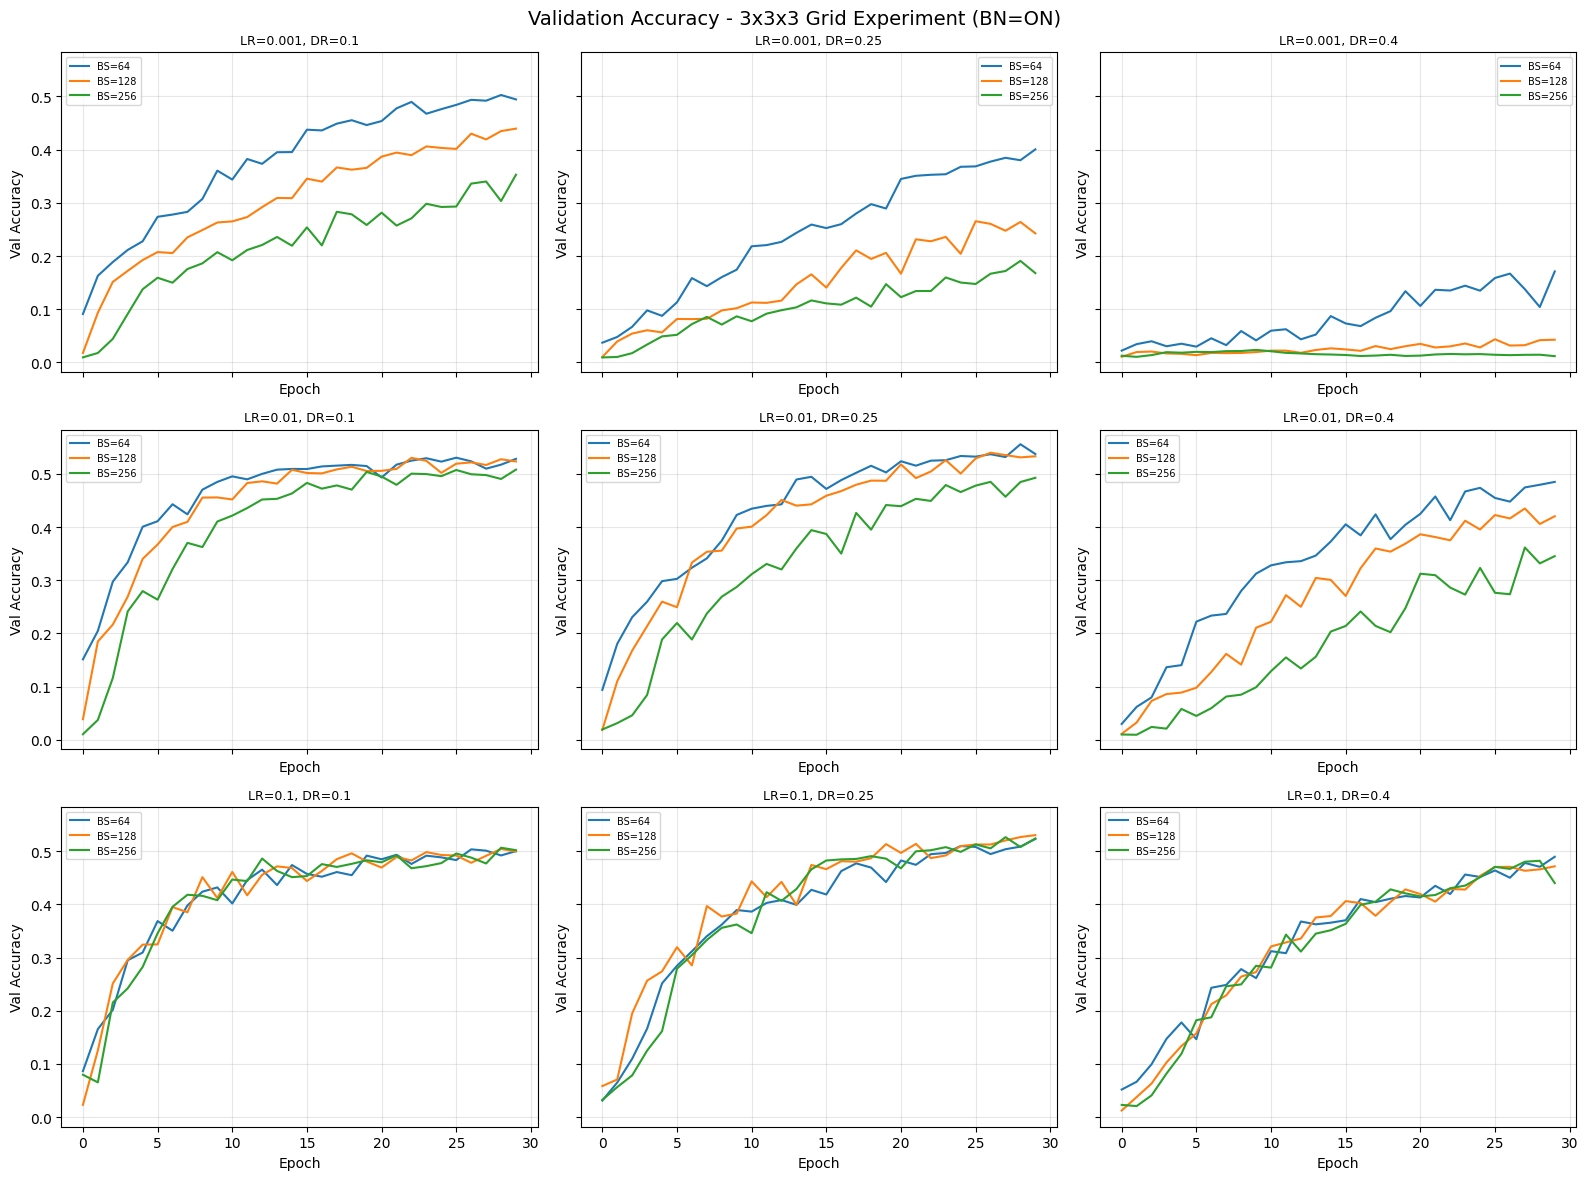

Plot saved to grid_val_accuracy.png


In [ ]:
# Plot: Validation accuracy curves
# One subplot per (LR x Dropout) combination,
# each batch size as a separate line.
# Layout: 3 rows (LR) x 3 cols (Dropout)
fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle('Validation Accuracy - 3x3x3 Grid Experiment (BN=ON)', fontsize=14)

for row_idx, lr in enumerate(LEARNING_RATE_OPTIONS):
    for col_idx, dr in enumerate(DROPOUT_RATE_OPTIONS):
        ax = axes[row_idx][col_idx]
        ax.set_title(f"LR={lr}, DR={dr}", fontsize=9)

        for r in results:
            if r['learning_rate'] == lr and r['dropout_rate'] == dr:
                ax.plot(r['history']['val_accuracy'],
                        label=f"BS={r['batch_size']}")

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Val Accuracy')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grid_val_accuracy.png', dpi=150)
plt.show()
print('Plot saved to grid_val_accuracy.png')

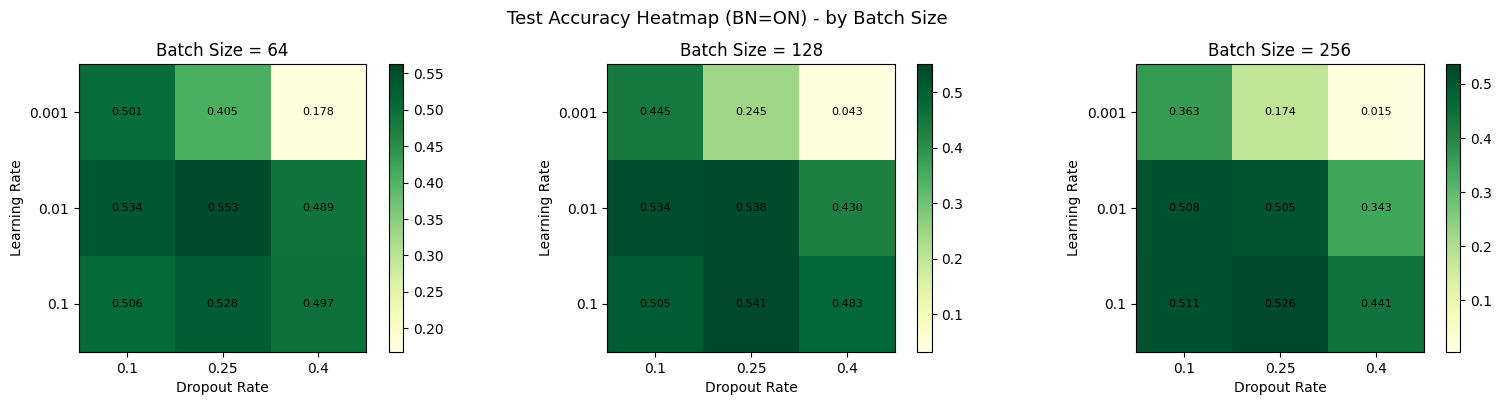

Heatmap saved to grid_heatmap.png


In [ ]:
# Heatmaps: Test accuracy for (LR x Dropout),
# one heatmap per batch size
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Test Accuracy Heatmap (BN=ON) - by Batch Size', fontsize=13)

for ax, bs in zip(axes, BATCH_SIZE_OPTIONS):
    matrix = np.zeros((len(LEARNING_RATE_OPTIONS), len(DROPOUT_RATE_OPTIONS)))
    for r in results:
        if r['batch_size'] == bs:
            i = LEARNING_RATE_OPTIONS.index(r['learning_rate'])
            j = DROPOUT_RATE_OPTIONS.index(r['dropout_rate'])
            matrix[i, j] = r['test_accuracy']

    im = ax.imshow(matrix, cmap='YlGn',
                   vmin=matrix.min() - 0.01,
                   vmax=matrix.max() + 0.01)
    ax.set_xticks(range(len(DROPOUT_RATE_OPTIONS)))
    ax.set_xticklabels(DROPOUT_RATE_OPTIONS)
    ax.set_yticks(range(len(LEARNING_RATE_OPTIONS)))
    ax.set_yticklabels(LEARNING_RATE_OPTIONS)
    ax.set_xlabel('Dropout Rate')
    ax.set_ylabel('Learning Rate')
    ax.set_title(f"Batch Size = {bs}")
    plt.colorbar(im, ax=ax)

    for i in range(len(LEARNING_RATE_OPTIONS)):
        for j in range(len(DROPOUT_RATE_OPTIONS)):
            ax.text(j, i, f"{matrix[i,j]:.3f}",
                    ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('grid_heatmap.png', dpi=150)
plt.show()
print('Heatmap saved to grid_heatmap.png')

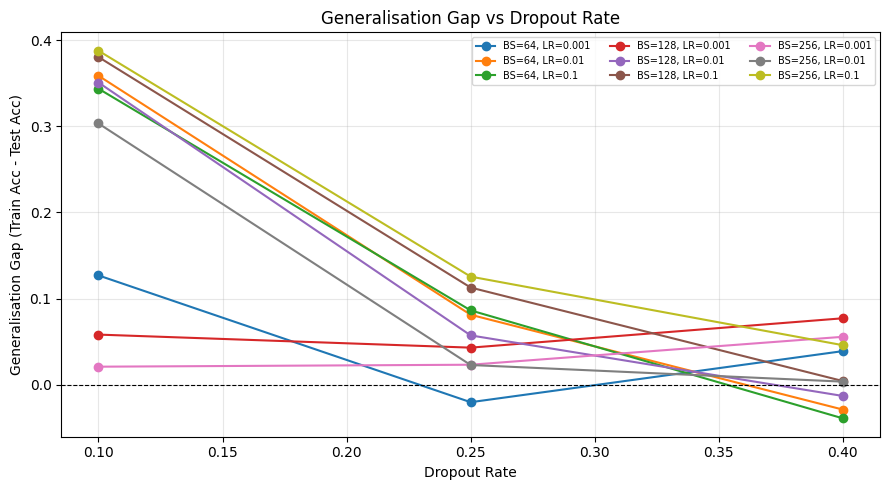

Generalisation gap plot saved to grid_gen_gap.png


In [ ]:
# Plot: Generalisation gap by dropout rate
# Shows how dropout regularisation affects overfitting
fig, ax = plt.subplots(figsize=(9, 5))

for bs in BATCH_SIZE_OPTIONS:
    for lr in LEARNING_RATE_OPTIONS:
        gaps = []
        for dr in DROPOUT_RATE_OPTIONS:
            r = next(x for x in results
                     if x['batch_size'] == bs
                     and x['learning_rate'] == lr
                     and x['dropout_rate'] == dr)
            gaps.append(r['final_train_acc'] - r['test_accuracy'])
        ax.plot(DROPOUT_RATE_OPTIONS, gaps,
                marker='o', label=f"BS={bs}, LR={lr}")

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Dropout Rate')
ax.set_ylabel('Generalisation Gap (Train Acc - Test Acc)')
ax.set_title('Generalisation Gap vs Dropout Rate')
ax.legend(fontsize=7, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grid_gen_gap.png', dpi=150)
plt.show()
print('Generalisation gap plot saved to grid_gen_gap.png')